In [109]:
import os
import numpy as np 
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from datetime import datetime
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [110]:
EXECUTION_TITLE = "MinMaxScaler_BiDirectionalDense64Tanh"

if not os.path.exists(EXECUTION_TITLE):
    os.mkdir(EXECUTION_TITLE)

In [111]:
print("TensorFlow version:", tf.__version__)
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [112]:
def to_usd(val) -> float:
    return round(val / 1000000, 2)

In [113]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [114]:
data = pd.read_csv("https://raw.githubusercontent.com/AjengSF015/Data-Apple-Stock-Price/refs/heads/main/Apple%20Stock%20Price.csv", delimiter=";")

data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,12/12/1980,128348,128906,128348,128348,99319,469033600
1,15/12/1980,122210,122210,121652,121652,94137,175884800
2,16/12/1980,113281,113281,112723,112723,87228,105728000
3,17/12/1980,115513,116071,115513,115513,89387,86441600
4,18/12/1980,118862,119420,118862,118862,91978,73449600


In [115]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

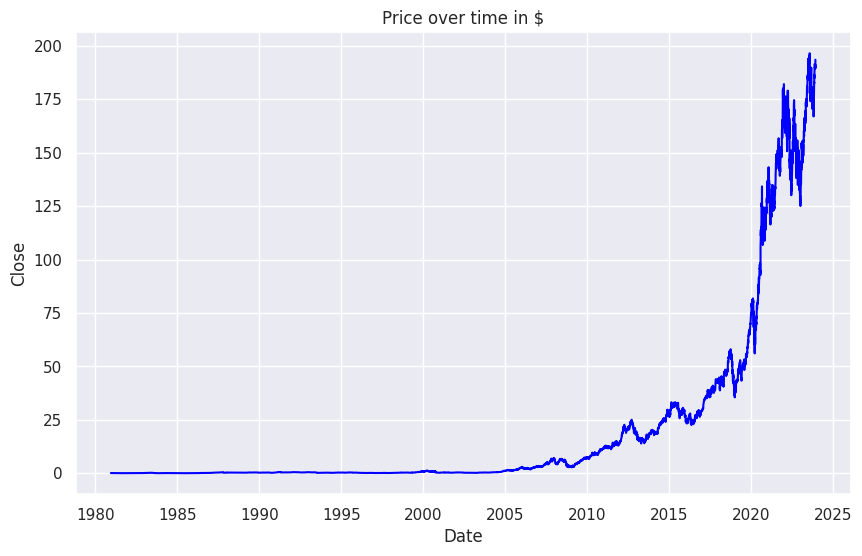

In [116]:
prediction = data.loc[
    (data['Date'] > datetime(2013,8,15)) &
    (data['Date'] < datetime(2013,12,5))
]


sns.set_theme(style="darkgrid", palette='pastel')

plt.subplots(figsize=(10, 6))
sns.lineplot(data=data, x='Date', y=to_usd(data['Close']), color='blue')
plt.title("Price over time in $")

plt.savefig(f"{EXECUTION_TITLE}/full_data.jpg")

In [117]:
# Prepare for the LSTM Model (Sequential)
stock_close = data.filter(["Close"])
dataset = stock_close.values #convert to numpy array
training_data_len = int(np.ceil(len(dataset) * 0.95))

In [118]:
scaler = MinMaxScaler((-1, 1))
scaled_data = scaler.fit_transform(dataset)

# scaled_data ()

In [119]:
training_data = scaled_data[:training_data_len]

In [120]:
X_train, y_train = [], []

In [121]:
for i in range(60, len(training_data)):
    X_train.append(training_data[i-60:i, 0])
    y_train.append(training_data[i,0])
    
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [122]:
print(f"Items per sequence: {len(X_train[0])}")
print(f"Count of sequences: {len(X_train)}")

Items per sequence: 60
Count of sequences: 10235


In [123]:
# Build the Model
model = keras.models.Sequential(name="appl_stock_price_lstm")

# Input Layer
model.add(keras.layers.InputLayer(shape=(60, 1)))

# Hidden Layers
# model.add(keras.layers.LSTM(64, return_sequences=True))
# model.add(keras.layers.LSTM(64, return_sequences=False))
# model.add(keras.layers.Dense(128, activation="relu"))
# model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Bidirectional(keras.layers.LSTM(64, activation='tanh')))
model.add(keras.layers.Dense(64, activation='tanh'))
model.add(keras.layers.Dropout(0.5))

# Output Layer
model.add(keras.layers.Dense(1))

# Output Model Info
model.summary()
model.compile(optimizer="adam",
              loss="mae",
              metrics=[keras.metrics.RootMeanSquaredError()])

Model: "appl_stock_price_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_9 (Bidirectional) │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,113 (164.50 KB)

 Trainable params: 42,113 (164.50 KB)

 Non-trainable params: 0 (0.00 B)

In [124]:
# Train model on data
training = model.fit(X_train, y_train, epochs=40, batch_size=32)

Epoch 1/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1063 - root_mean_squared_error: 0.1426
Epoch 2/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0834 - root_mean_squared_error: 0.1053
Epoch 3/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0736 - root_mean_squared_error: 0.0938
Epoch 4/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0635 - root_mean_squared_error: 0.0809
Epoch 5/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0540 - root_mean_squared_error: 0.0694
Epoch 6/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0460 - root_mean_squared_error: 0.0603
Epoch 7/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0382 - root_mean_squared_error: 0.0513
Epoch 8/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0318 - root_mean_squared_error: 0.0443
Epoch 9/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0262 - root_mean_squared_error: 0.0390
Epoch 10/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0221 - root_mean_squared_err

Text(0.5, 1.0, 'Root Mean Squared Error')

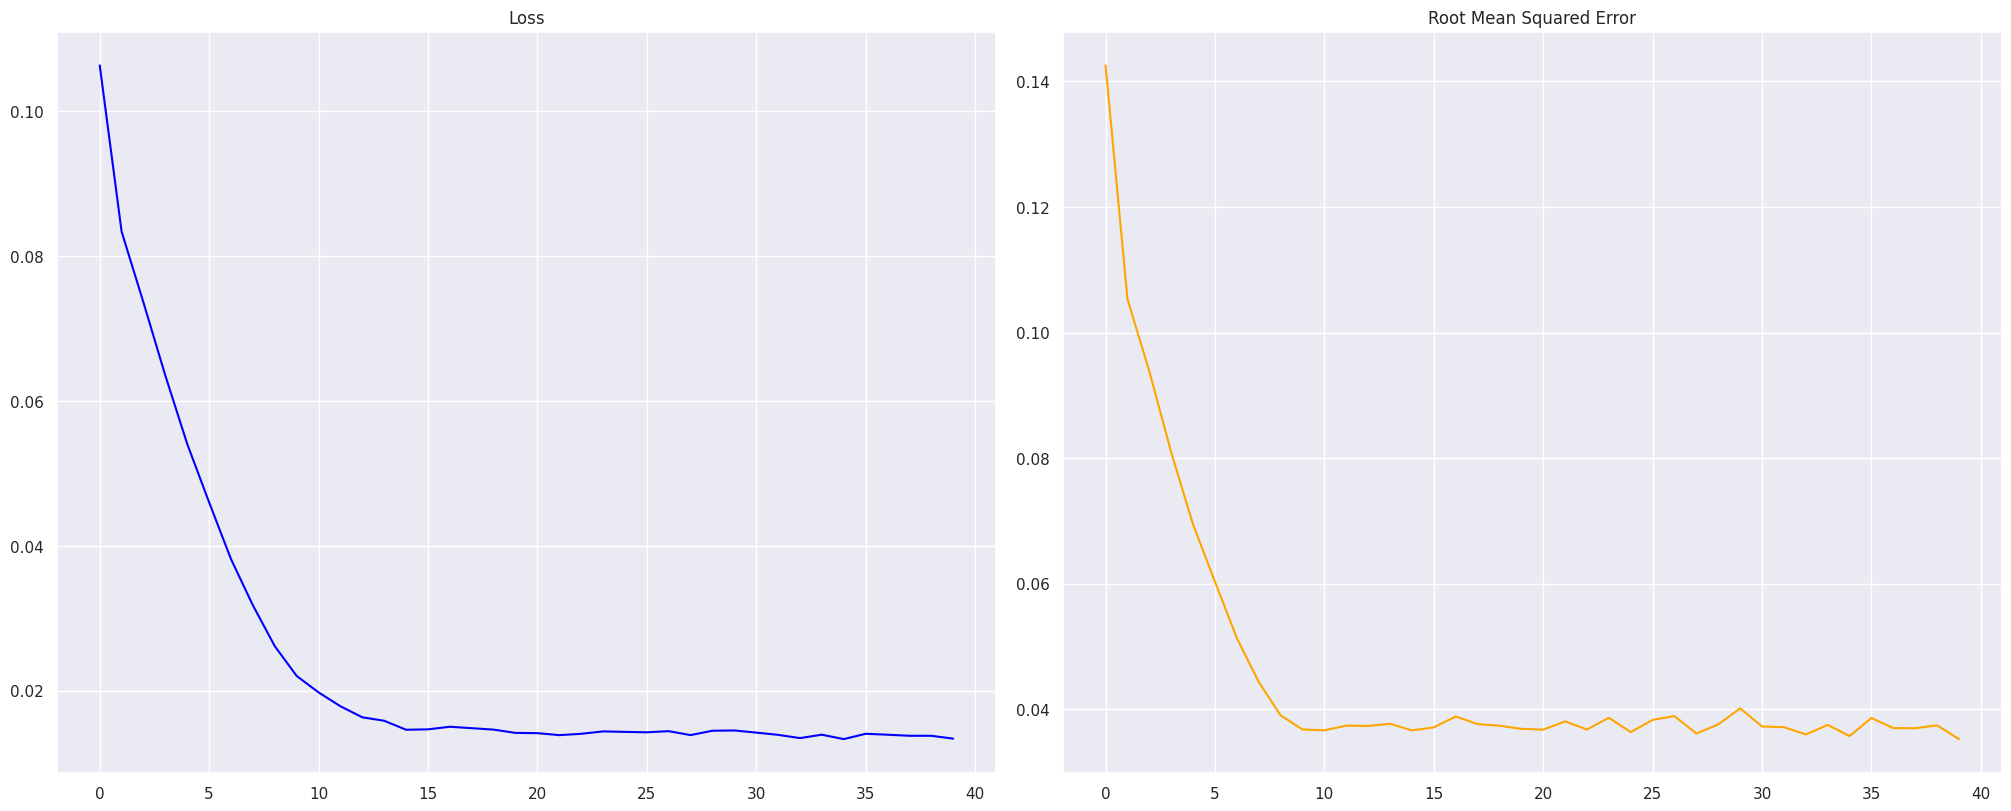

In [125]:
fig, ax = plt.subplots(ncols=2, layout='constrained')

fig.set_figheight(8)
fig.set_figwidth(20)

# Left Plot loss
sns.lineplot(training.history['loss'], color='blue', ax=ax[0])
ax[0].set_title("Loss")

# Left Plot root_mean_squared_error
sns.lineplot(training.history['root_mean_squared_error'], color='orange', ax=ax[1])
ax[1].set_title("Root Mean Squared Error")

In [126]:
# Prep the test data
test_data = scaled_data[training_data_len - 60:]
X_test, y_test = [], dataset[training_data_len:]


for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1 ))

# Make a Prediction
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)


# Plotting data
train = data[:training_data_len]
test =  data[training_data_len:]

test = test.copy()

test['Predictions'] = predictions

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


Text(0.5, 1.0, 'Prediction vs Actual w/o History')

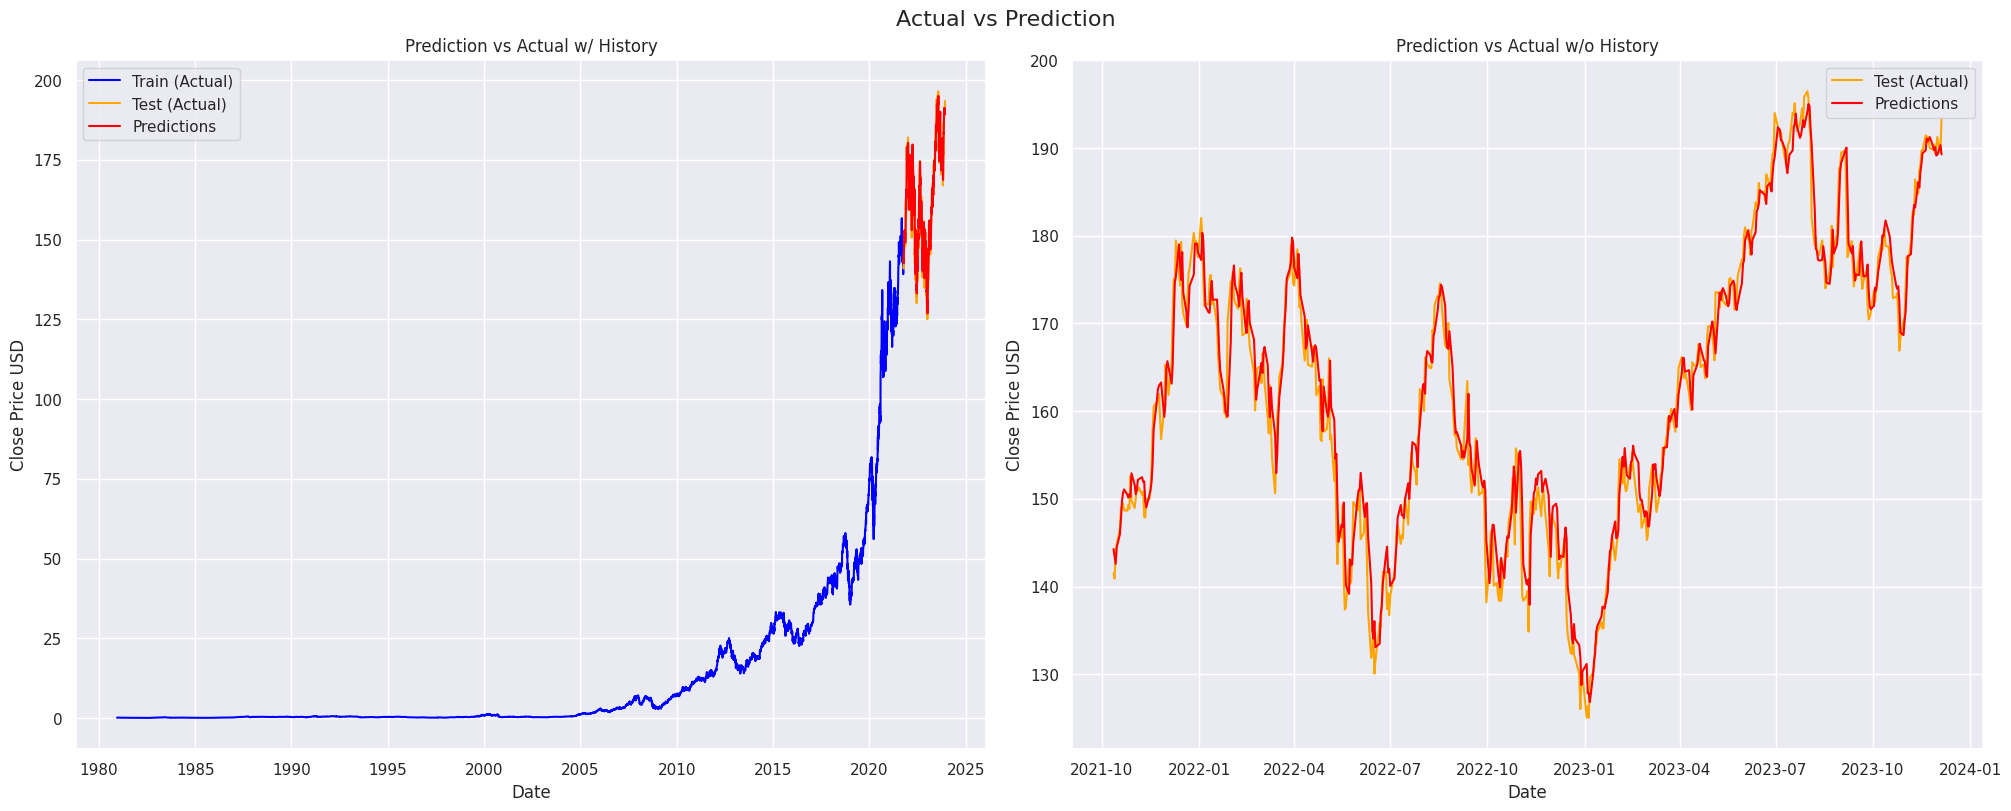

In [127]:
# Plot Predictions
fig, ax = plt.subplots(ncols=2, layout='constrained')

fig.set_figheight(8)
fig.set_figwidth(20)

fig.suptitle('Actual vs Prediction', fontsize=16)

# Left Plot with history
sns.lineplot(x=train['Date'], y=to_usd(train['Close']), label="Train (Actual)", color='blue', ax=ax[0])
sns.lineplot(x=test['Date'], y=to_usd(test['Close']), label="Test (Actual)", color='orange', ax=ax[0])
sns.lineplot(x=test['Date'], y=to_usd(test['Predictions']), label="Predictions", color='red', ax=ax[0])
ax[0].set_ylabel("Close Price USD")
ax[0].set_title("Prediction vs Actual w/ History")

# Left Plot no history
sns.lineplot(x=test['Date'], y=to_usd(test['Close']), label="Test (Actual)", color='orange', ax=ax[1])
sns.lineplot(x=test['Date'], y=to_usd(test['Predictions']), label="Predictions", color='red', ax=ax[1])
ax[1].set_ylabel("Close Price USD")
ax[1].set_title("Prediction vs Actual w/o History")

Text(0, 0.5, 'Relative Error')

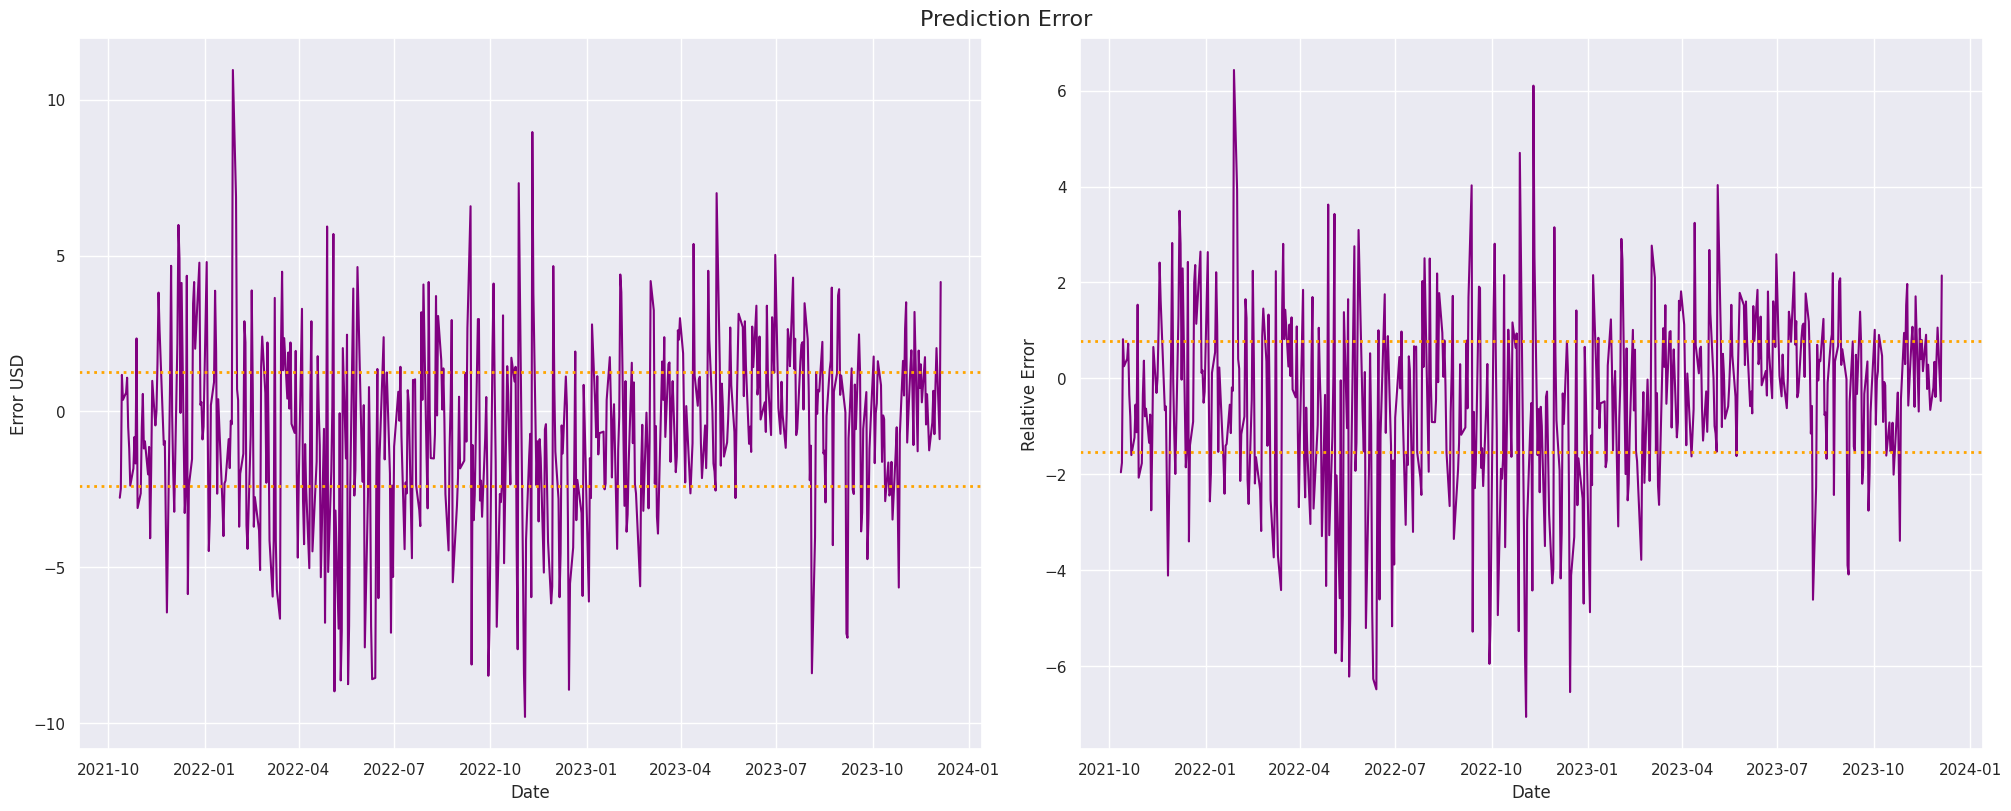

In [128]:
test['Error_usd'] = to_usd(test['Close'] - test['Predictions'])
test['Error_pct'] = ((test['Close'] - test['Predictions']) / test['Close']) * 100

err_usd_desc = test['Error_usd'].describe().to_dict()
err_pct_desc = test['Error_pct'].describe().to_dict()


# Plot Error
fig, ax = plt.subplots(ncols=2, layout='constrained')

fig.set_figheight(8)
fig.set_figwidth(20)

fig.suptitle('Prediction Error', fontsize=16)

# Left Plot with history
sns.lineplot(x=test['Date'], y=test['Error_usd'], color='purple', ax=ax[0])
ax[0].set_ylabel("Error USD")
ax[0].axhline(y=err_usd_desc['25%'], linewidth=2, color='orange', ls=':')
ax[0].axhline(y=err_usd_desc['75%'], linewidth=2, color='orange', ls=':')

# Left Plot no history
sns.lineplot(x=test['Date'], y=test['Error_pct'], color='purple', ax=ax[1])
ax[1].axhline(y=err_pct_desc['25%'], linewidth=2, color='orange', ls=':')
ax[1].axhline(y=err_pct_desc['75%'], linewidth=2, color='orange', ls=':')
ax[1].set_ylabel("Relative Error")

Text(0, 0.5, 'Relative Error')

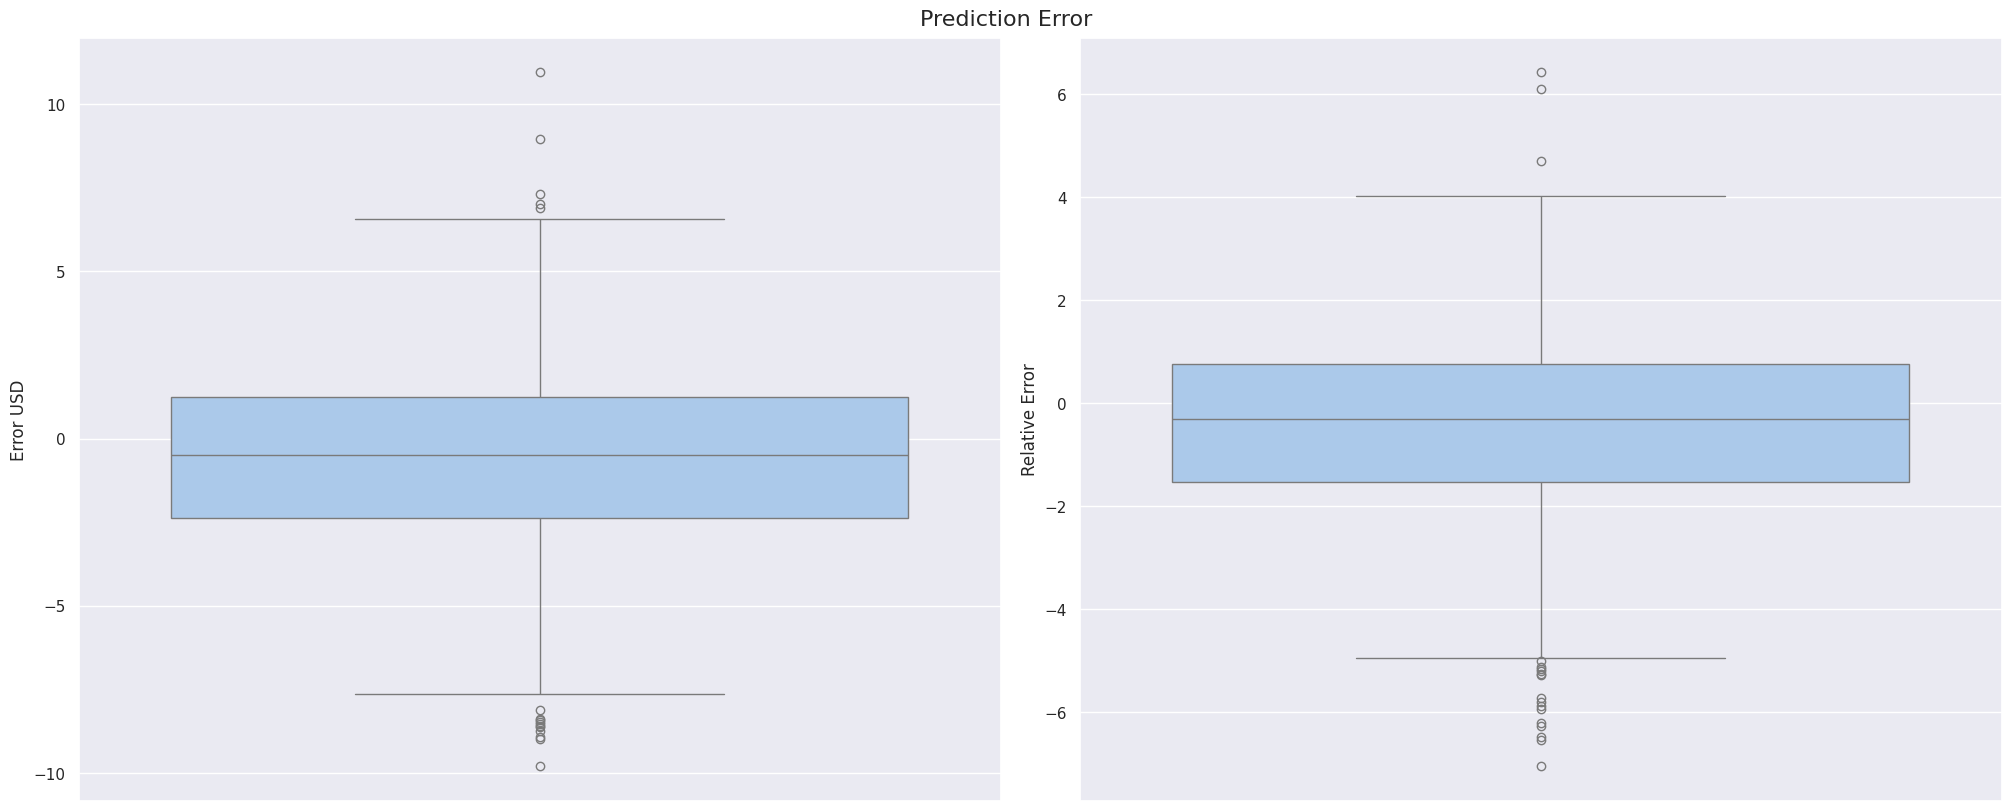

In [129]:
# Boxplot Error
fig, ax = plt.subplots(ncols=2, layout='constrained')

fig.set_figheight(8)
fig.set_figwidth(20)


fig.suptitle('Prediction Error', fontsize=16)

sns.boxplot(test, y="Error_usd", ax=ax[0])
ax[0].set_ylabel("Error USD")

sns.boxplot(test, y="Error_pct", ax=ax[1])
ax[1].set_ylabel("Relative Error")